# Model Ablation Experiments

Here, we perform various ablation studies to isolate the contribution of different components of our model architecture and training pipeline. This includes:

1. Freezing Ablation: We compare the performance of the model when the last 4 blocks of the ViT backbone are unfrozen vs. unfreezing only the first 2 blocks (the "Stem"). This helps us understand how much fine-tuning of the ViT is necessary for good performance.

2. Temporal Pooling Ablation: We compare different temporal pooling strategies (e.g., Global Average Pooling, max pooling, attention-based pooling) to see which one best captures the temporal dynamics of the video frames. As Deepfake artifacts can appear in just 2-3 frames and the "last" frame might be clean, this ablation can confirm correct capturing of temporal information.

3. Training Technique Ablation: We experiment with different training techniques such as Supervised Contrastive Loss, Binary Cross-Entropy (BCE), and Focal Loss to see how they affect convergence and final performance.

##### Import libraries

In [21]:
import cv2
import timm
import pandas as pd
import torch.nn as nn
import mediapipe as mp
import torch.optim as optim

import os
import sys
import h5py
import torch
import numpy as np
import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torchaudio.transforms as transforms
from torch.utils.data import Dataset, DataLoader

curr_dir = os.getcwd()
root_dir = os.path.dirname(curr_dir)
data_dir = os.path.join(root_dir, 'data')

if root_dir not in sys.path:
	sys.path.append(root_dir)

import aceverify

# Setting HuggingFace token for accessing pretrained models faster
os.environ['HF_HOME'] = os.path.join(root_dir, 'huggingface')
os.environ['HF_TOKEN'] = "" # TODO: Update with your HuggingFace token

In [6]:
class AblationACEModel(nn.Module):
    def __init__(self, unfreeze_mode='last4', pooling_mode='last_state', loss_mode='BCE'):
        super().__init__()
        self.pooling_mode = pooling_mode
        self.video_model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)

        # Freezing Ablation
        for param in self.video_model.parameters():
            param.requires_grad = False
            
        if unfreeze_mode == 'last4':
            for param in self.video_model.blocks[-4:].parameters():
                param.requires_grad = True
        elif unfreeze_mode == 'stem':
            for param in self.video_model.patch_embed.parameters(): # Unfreeze Patch Embeddings and first 2 blocks
                param.requires_grad = True
            for param in self.video_model.blocks[:2].parameters():
                param.requires_grad = True

        self.temporal_layer = nn.GRU(768, 512, batch_first=True, bidirectional=True)
        
        # Pooling Ablation
        if pooling_mode == 'attention':
            self.att_weights = nn.Linear(1024, 1)

        self.video_norm = nn.LayerNorm(1024)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 1)
        )

    def forward(self, video, audio=None):
        B, C, T, H, W = video.shape
        video = video.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)
        v_feat = self.video_model(video).reshape(B, T, 768)
        gru_out, _ = self.temporal_layer(v_feat) # [B, T, 1024]

        # Pooling Ablations
        if self.pooling_mode == 'last_state':
            pooled = gru_out[:, -1, :]
        elif self.pooling_mode == 'avg':
            pooled = torch.mean(gru_out, dim=1)
        elif self.pooling_mode == 'max':
            pooled, _ = torch.max(gru_out, dim=1)
        elif self.pooling_mode == 'attention':
            weights = torch.tanh(self.att_weights(gru_out))
            weights = torch.softmax(weights, dim=1)
            pooled = torch.sum(weights * gru_out, dim=1)

        return self.classifier(self.video_norm(pooled))

##### Utility Function for Results Comparision

In [16]:
def summary_table(results_dict, category_name):
    data = []
    for mode, metrics in results_dict.items():
        data.append({
            category_name: mode,
            'Best Test Accuracy': f"{max(metrics['test_accuracies']):.2f}%",
            'Best Train Accuracy': f"{max(metrics['train_accuracies']):.4f}"
        })
    return pd.DataFrame(data)

##### Global Settings & Hyperparameters

In [19]:
# Hyperparameters & Parameters for training
epochs = 10
batch_size = 8
learning_rate = 5e-5
train_path = "/rhome/abhar061/shared/ace_verify/data/train_data-003.h5"
test_path = "/rhome/abhar061/shared/ace_verify/data/test_data.h5"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]).to(device))

config = {
    "device":device,
    "criterion": criterion,
    "epochs": epochs,
    "batch_size": batch_size,
    "test_path": test_path,
    "train_path": train_path,
}

SEED = 42

# Fetching common Test Indices for fair comparison amongst all the models
def fixed_balanced_indices(path, n, seed=42):
    rng = np.random.default_rng(seed)
    with h5py.File(path, "r") as f:
        labels = np.array([f[k].attrs["label"] for k in f.keys()])

    real_indices = np.where(labels == 0)[0]
    fake_indices = np.where(labels == 1)[0]
    num_each = n // 2

    sel_real = rng.choice(real_indices, min(len(real_indices), num_each), replace=False)
    sel_fake = rng.choice(fake_indices, min(len(fake_indices), num_each), replace=False)

    indices = np.concatenate([sel_real, sel_fake])
    rng.shuffle(indices)
    return indices

test_n = 200
test_indices = fixed_balanced_indices(test_path, test_n, seed=SEED)
config["test_indices"] = test_indices

results_dir = os.path.join(root_dir, "results")
os.makedirs(results_dir, exist_ok=True)

def plot_comparison(results, ablation_name):
    sns.set_style("white")
    plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
    
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
    
    # Color palette
    colors = sns.color_palette("Set1", n_colors=len(results))
    
    for i, (experiment_name, metrics) in enumerate(results.items()):
        color = colors[i]
        epochs = metrics['epochs']
        
        # Plotting Test Accuracy with Solid Line (-) as it's the Primary Focus
        ax.plot(epochs, metrics['test_accuracies'], 
                label=f"{experiment_name} (Test: {max(metrics['test_accuracies']):.1f}%)", 
                color=color, linestyle='-', linewidth=2.5)
        
        # Plotting Train Accuracy with Dashed Line (--) as it's Secondary Focus
        ax.plot(epochs, metrics['train_accuracies'], 
                label=f"{experiment_name} (Train: {max(metrics['train_accuracies']):.1f}%)", 
                color=color, linestyle='--', linewidth=1.5, alpha=0.7)
        
        # Marking the peak test accuracy
        best_acc = max(metrics['test_accuracies'])
        best_epoch = epochs[metrics['test_accuracies'].index(best_acc)]
        ax.scatter(best_epoch, best_acc, color=color, s=40, edgecolors='black', zorder=5)

    # Labeling and Titles
    ax.set_title("Performance gain from Model Ablation Techniques", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Epochs", fontsize=14)
    ax.set_ylabel("Accuracy (%)", fontsize=14)
    
    # Refined Legend
    ax.legend(loc='lower right', frameon=True, fontsize=10, ncol=1)
    
    # Grid and Spines
    ax.grid(True, linestyle='--', alpha=0.6)
    sns.despine() # Removes top and right borders
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, f"{ablation_name}_ablation_comparison.pdf"), format='pdf', bbox_inches='tight') # Best for LaTeX
    plt.show()

##### Experiment 1: Freezing Ablation (Stem vs Last 4)

In [9]:
results_freezing = {}

for mode in ['last4', 'stem']:
    print(f"\nRunning Freezing Ablation: {mode}")
    model = AblationACEModel(unfreeze_mode=mode).cuda().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
    checkpoint_path = f"aceverify_ablation_freezing_{mode}.pth"

    config["model"] = model
    config["optimizer"] = optimizer
    config["scheduler"] = scheduler
    config["checkpoint_path"] = checkpoint_path

    _, results_freezing[mode] = aceverify.train_model(config)


Running Freezing Ablation: last4


No checkpoint found. Starting from pretrained ViT weights.



Running Freezing Ablation: stem


No checkpoint found. Starting from pretrained ViT weights.


In [18]:
df_freezing = summary_table(results_freezing, "Freezing Strategy")
print(df_freezing)

  Freezing Strategy Best Test Accuracy Best Train Accuracy
0             last4             74.00%             89.7000
1              stem             58.00%             61.7000


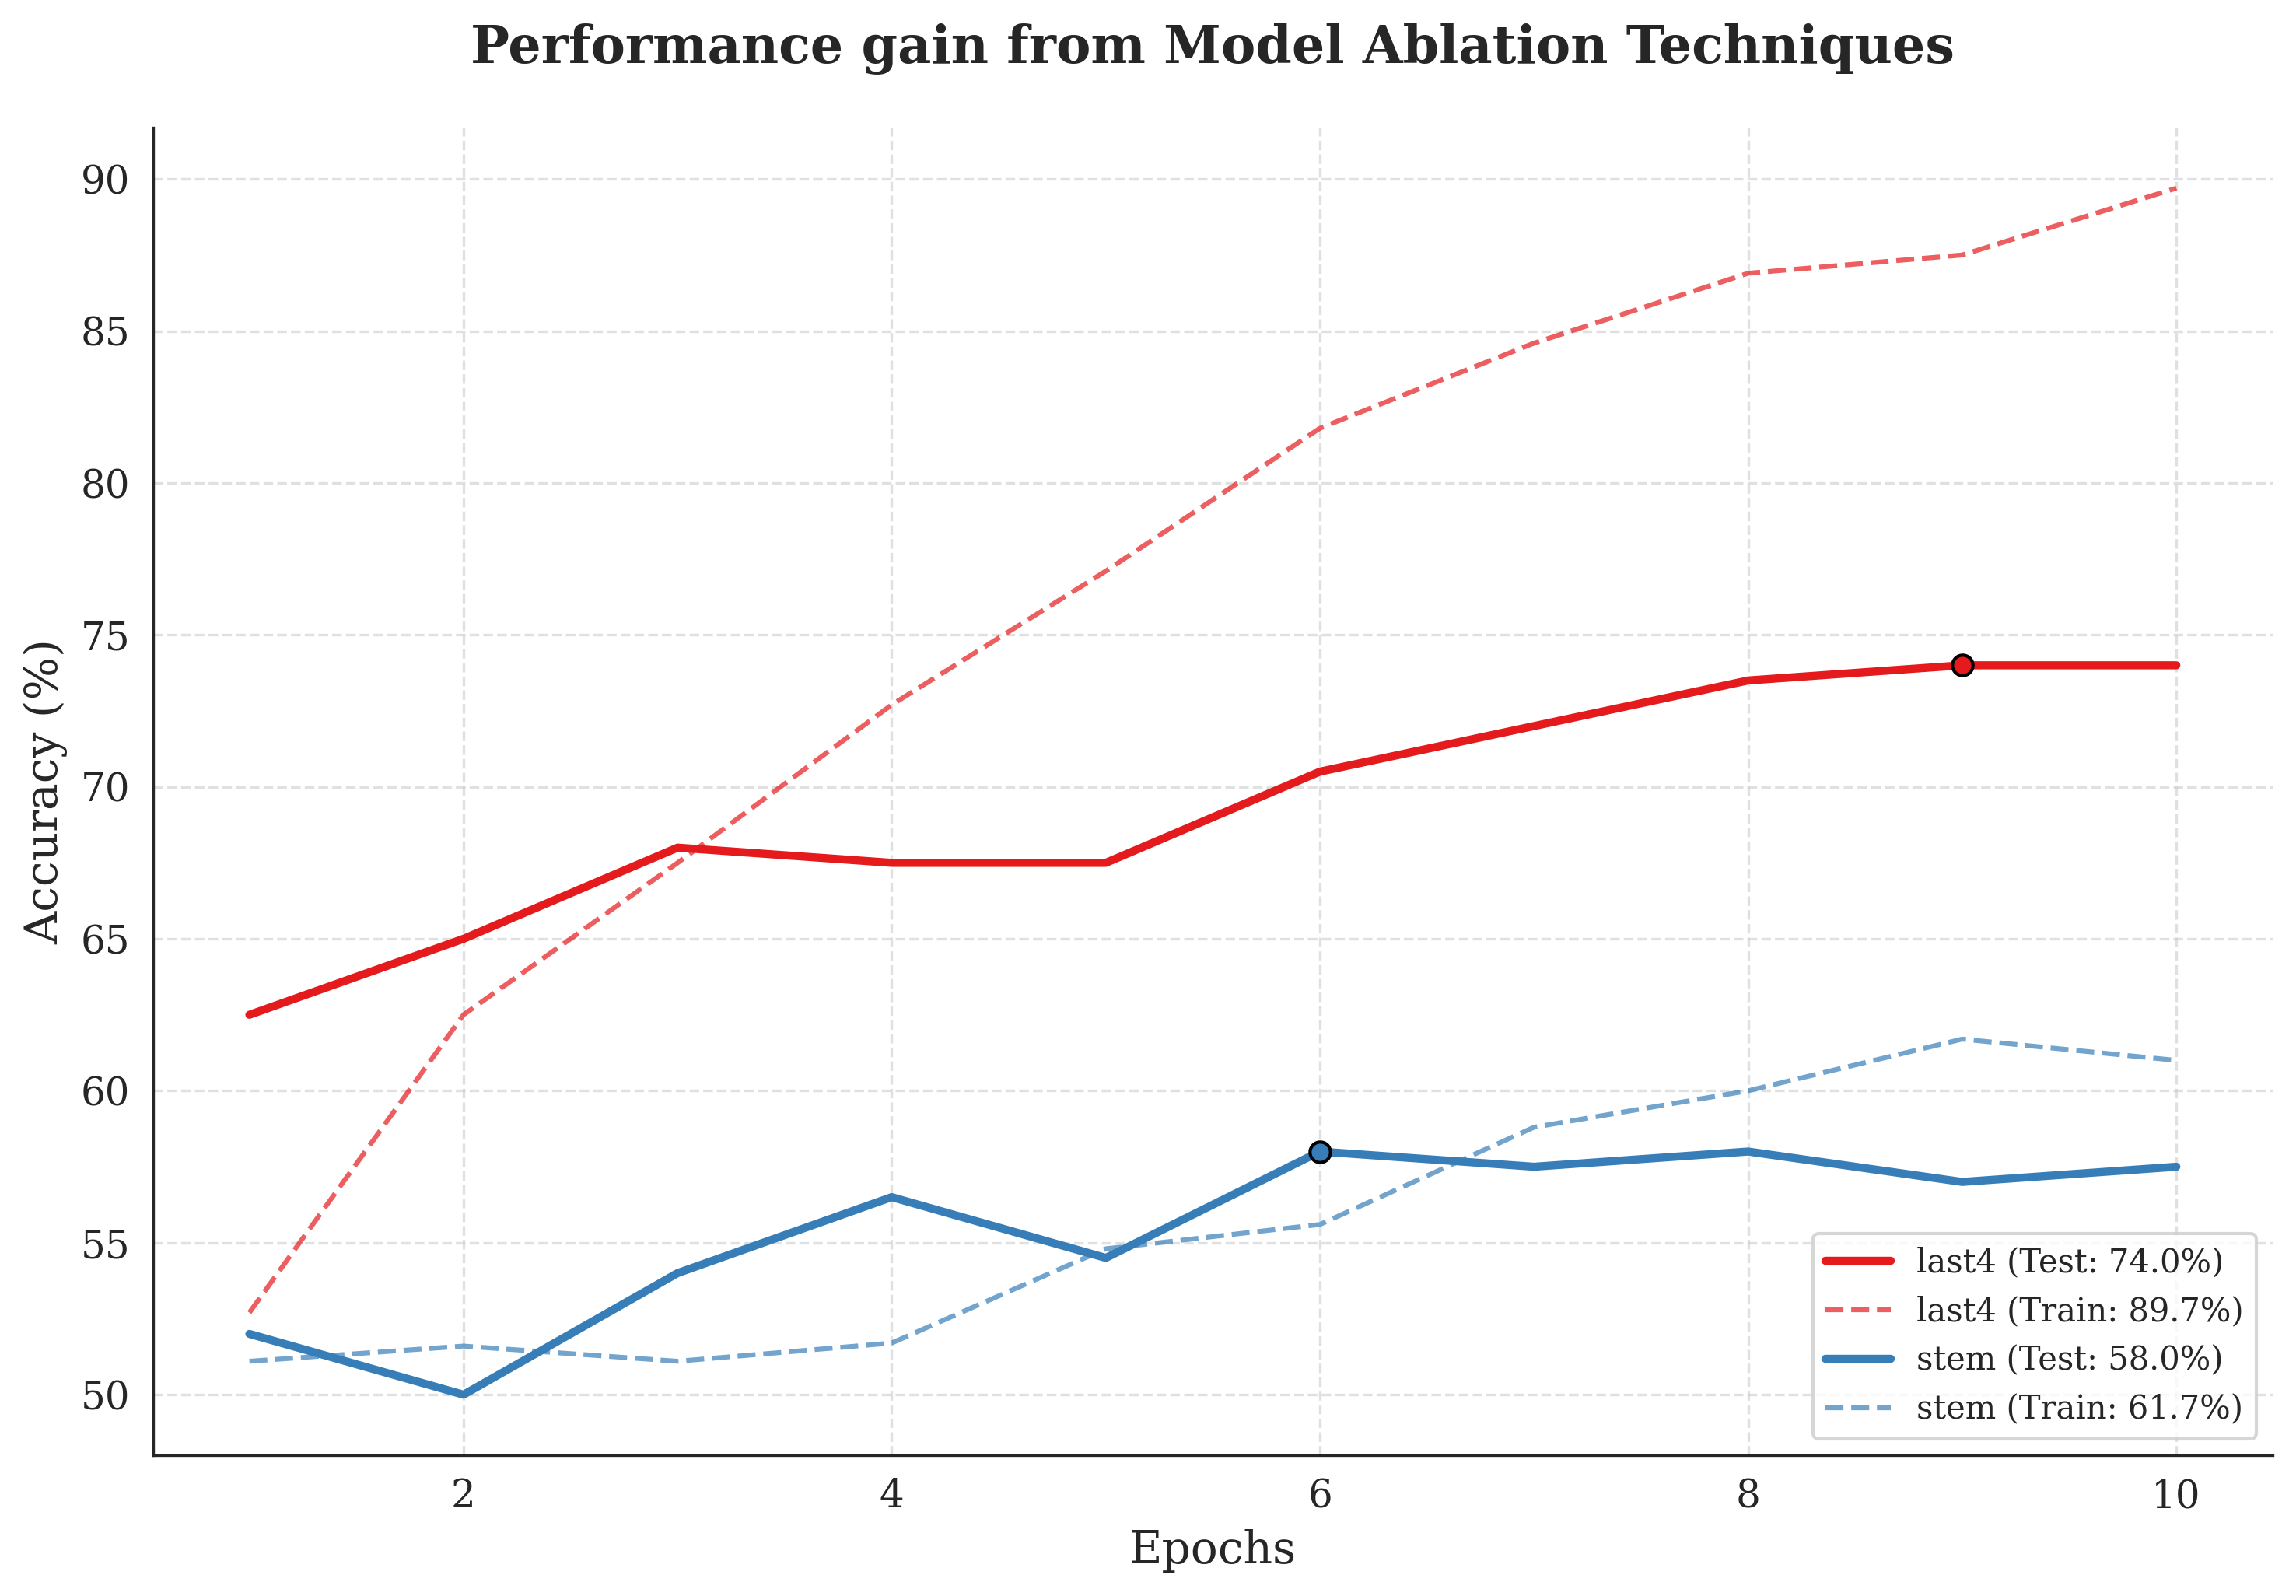

In [22]:
if results_freezing:
    plot_comparison(results_freezing, "freezing")
else:
    print("Run the experiments for Freezing Ablation first.")

From the above results, we observe that unfreezing the last 4 layers of the ViT backbone of our model generalized better to the test data then unfreezing it's stem (patch embedder + first 2 layers) by a significant margin (~16% for Test accuracy & ~28% for Train accuracy) which we attribute to the fact that the stem layers are more general-purpose and less specialized for the task of Deepfake detection, while the last 4 layers can learn more task-specific features that are crucial for distinguishing between real and fake videos.

##### Experiment 2: Temporal Pooling (Last vs. Avg vs. Attn)

In [ ]:
results_pooling = {}

for mode in ['last_state', 'avg', 'attention']:
    print(f"\nRunning Pooling Ablation: {mode}")
    model = AblationACEModel(pooling_mode=mode).cuda().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
    checkpoint_path = f"aceverify_ablation_pooling_{mode}.pth"

    config["model"] = model
    config["optimizer"] = optimizer
    config["scheduler"] = scheduler
    config["checkpoint_path"] = checkpoint_path
    
    results_pooling[mode] = aceverify.train_model(config)


Running Pooling Ablation: last_state


No checkpoint found. Starting from pretrained ViT weights.



Running Pooling Ablation: avg


No checkpoint found. Starting from pretrained ViT weights.



Running Pooling Ablation: attention


No checkpoint found. Starting from pretrained ViT weights.


In [ ]:
results_pooling_dict = {}

for key, val in results_pooling.items():
    results_pooling_dict[key] = val[1]

In [33]:
df_pooling = summary_table(results_pooling_dict, "Pooling Strategy")
print(df_pooling)

  Pooling Strategy Best Test Accuracy Best Train Accuracy
0       last_state             71.50%             87.8000
1              avg             75.50%             89.3000
2        attention             78.00%             89.8000


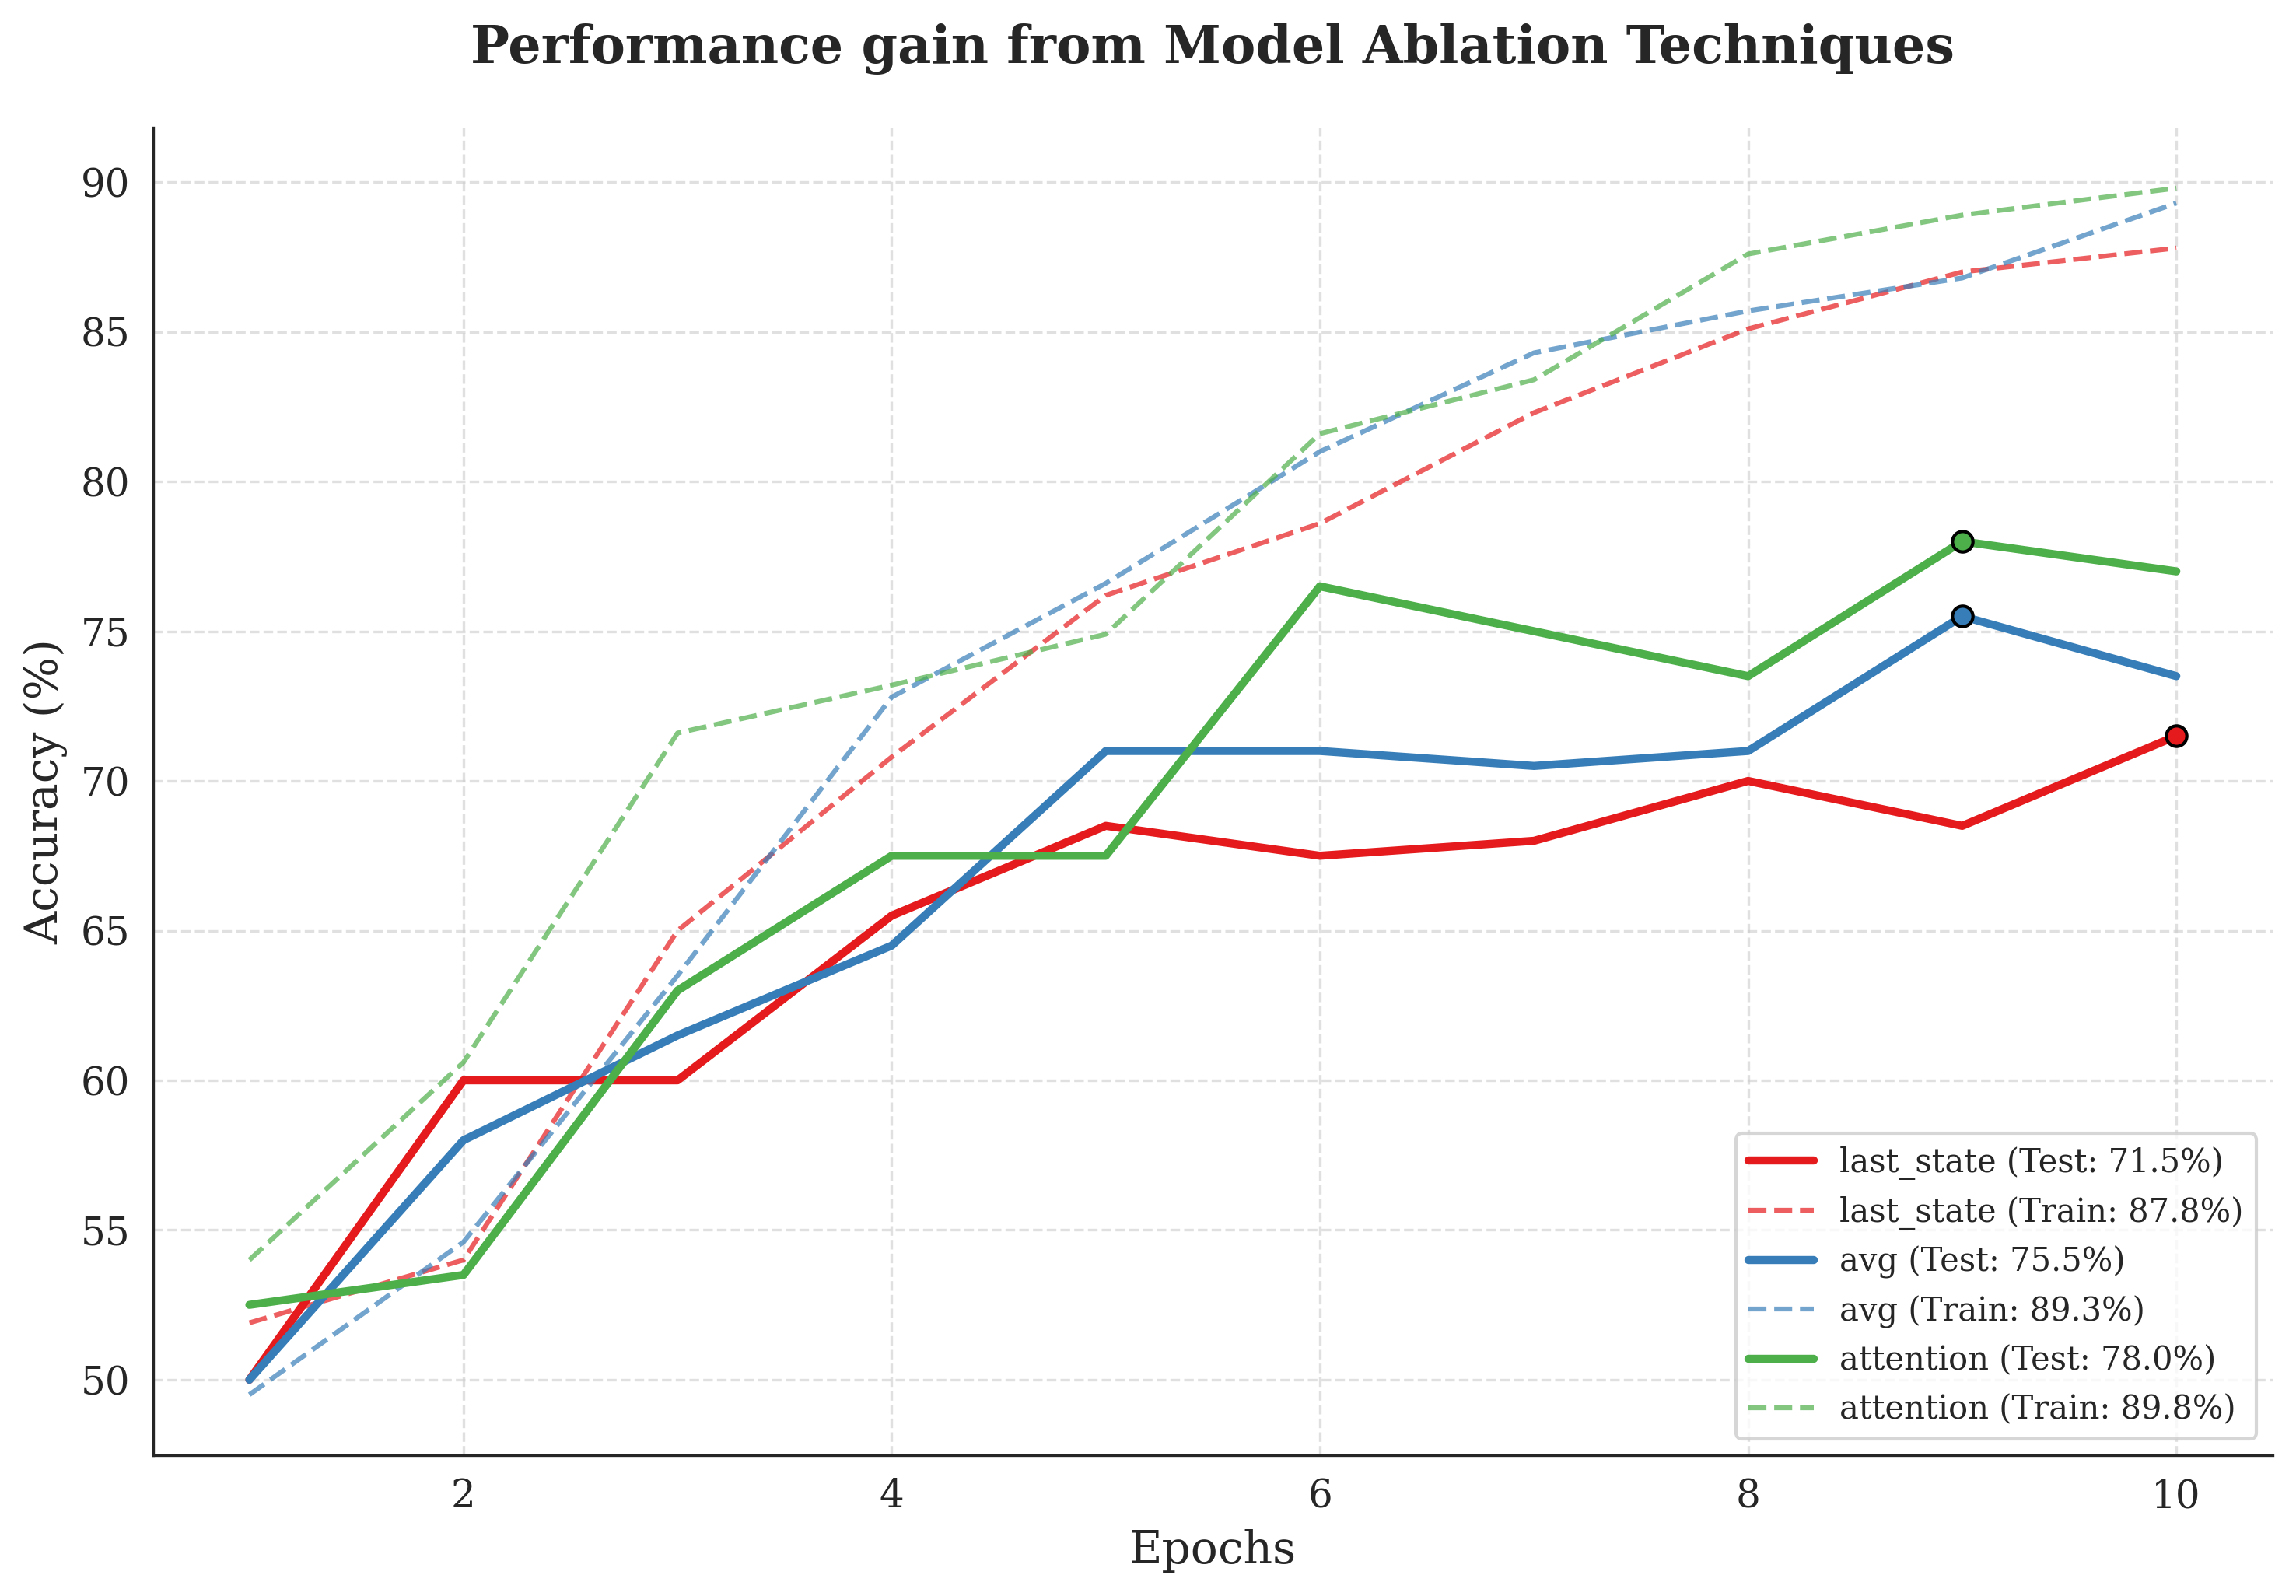

In [36]:
if results_pooling_dict:
    plot_comparison(results_pooling_dict, "pooling")
else:
    print("Run the experiments for Pooling Ablation first.")

From the above results, we observe that using attention-based pooling significantly outperforms both global average pooling and max pooling by a considerable margin (~2.5% and ~6.5% for Test accuracies & ~0.5% and 2% for Train accuracies) which we attribute to the fact that attention-based pooling can learn to focus on the most relevant frames in the video that contain Deepfake artifacts, while global average pooling and max pooling treat all frames equally and may dilute the signal from the important frames.

##### Experiment 3: Training Technique (BCE vs. Focal vs. SupCon)

In [37]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

In [38]:
results_criterion = {}
model = AblationACEModel(pooling_mode=mode).cuda().to(device)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
checkpoint_path = f"aceverify_ablation_criterion_{mode}.pth"

config["model"] = model
config["optimizer"] = optimizer
config["scheduler"] = scheduler
config["checkpoint_path"] = checkpoint_path

_, results_criterion["BCEWithLogitsLoss"] = aceverify.train_model(config)

config["criterion"] = FocalLoss()
_, results_criterion["FocalLoss"] = aceverify.train_model(config)

No checkpoint found. Starting from pretrained ViT weights.


In [39]:
df_criterion = summary_table(results_criterion, "Criterion Strategy")
print(df_criterion)

  Criterion Strategy Best Test Accuracy Best Train Accuracy
0  BCEWithLogitsLoss             76.50%             88.5000
1          FocalLoss             76.00%             92.1000


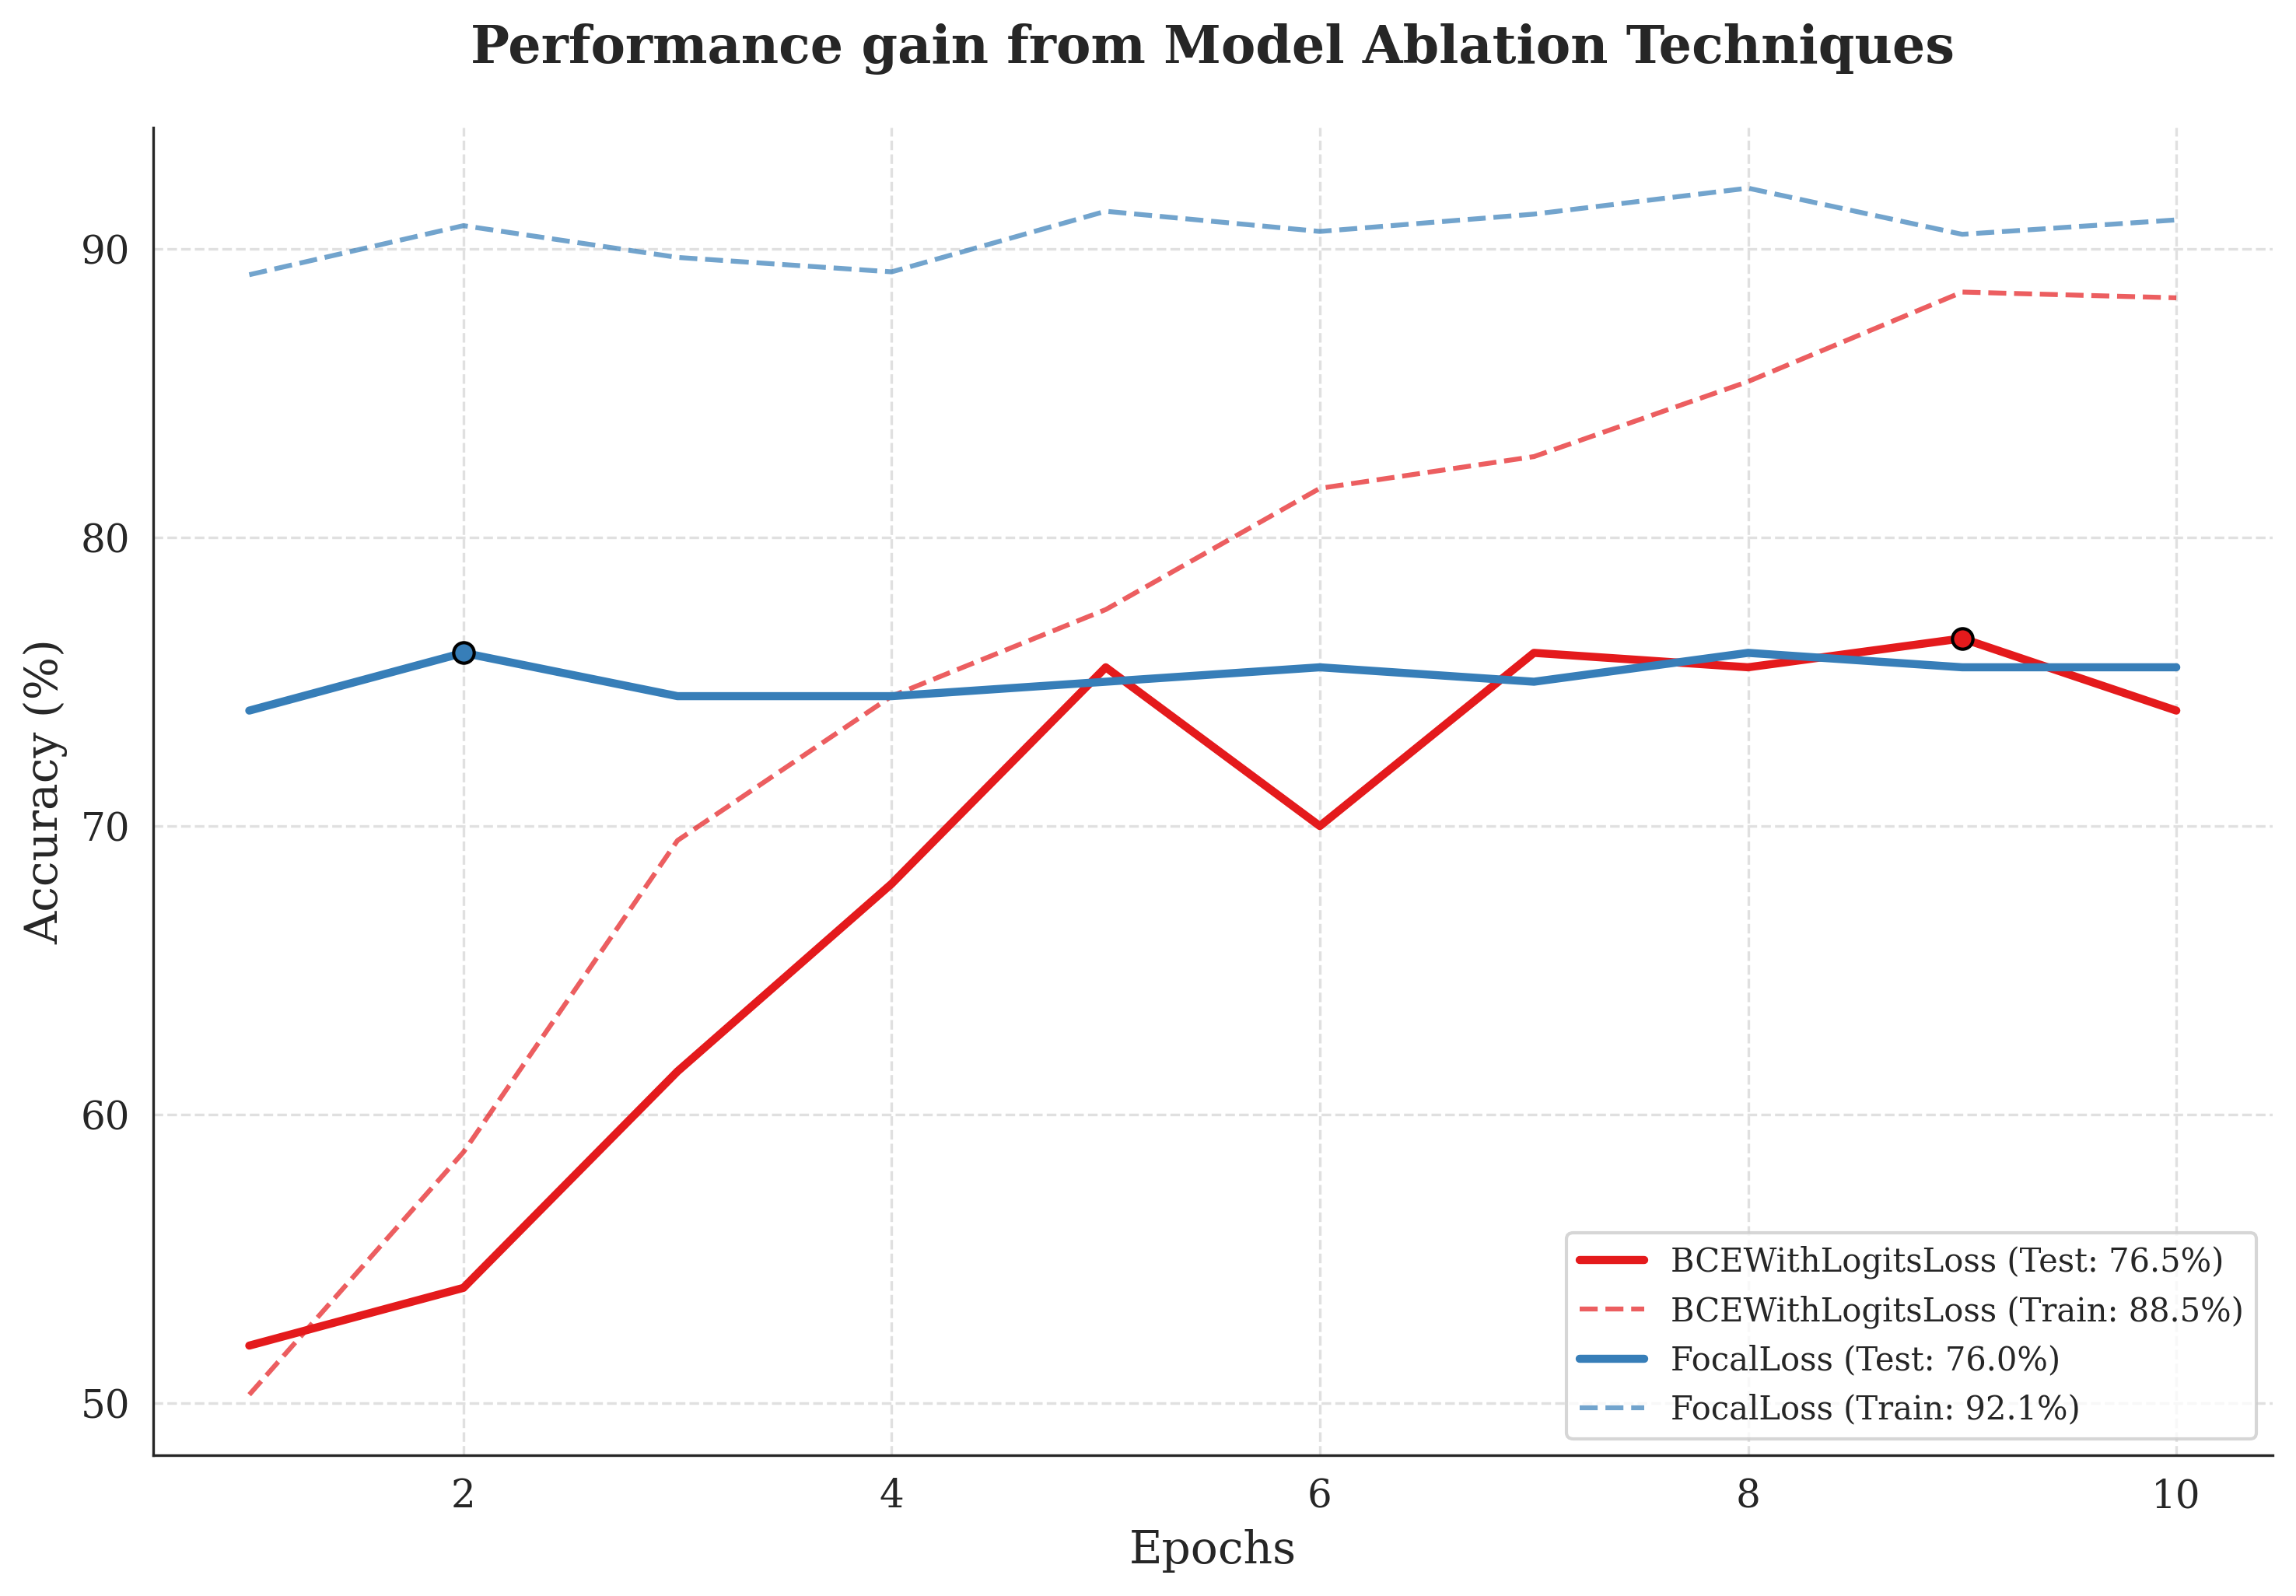

In [40]:
if results_criterion:
    plot_comparison(results_criterion, "criterion")
else:
    print("Run the experiments for Criterion Ablation first.")

Even though the model trained with Focal Loss converged faster and achieved higher training accuracy than the model trained with BCE, it performed slightly worse on the test set (by ~0.5%). The reason behind this stems from the almost stagnent accuracy curve from focal loss, which  we attribute to the fact that Focal Loss may lead to overfitting on the training data by encouraging the model to learn very specific features that do not generalize well to unseen data, while BCE Loss provides a more balanced learning signal that helps the model generalize better.